# WMS visualization

Minimal workflow using a real WMS from Python:

1. Build an **OWSLib** `WebMapService` client (it performs `GetCapabilities` and parses the XML).
2. Inspect layer titles and identifiers.
3. Pick the raster layer and its bounding box in **WGS 84** (EPSG:4326: longitude / latitude in degrees).
4. Request a map image with `getmap` using the same CRS.
5. Display it with `matplotlib` (axes in degrees).

The service advertises several CRS in the capabilities (e.g. Web Mercator and WGS 84). This notebook uses **EPSG:4326** so the plot axes read as latitude and longitude, not metres.

References:

- https://copernicus.discomap.eea.europa.eu/arcgis/rest/services/Natura2000/N2K_2018/MapServer
- https://copernicus.discomap.eea.europa.eu/ArcGIS/rest/services/Natura2000/N2K_2018/MapServer/layers
- https://www.eea.europa.eu/data-and-maps/data/copernicus-land-monitoring-service-natura-2000/natura-2000-updates/n2k-2018


In [44]:
from io import BytesIO

import matplotlib.pyplot as plt
from owslib.wms import WebMapService

WMS_URL = (
    "https://copernicus.discomap.eea.europa.eu/arcgis/services/"
    "Natura2000/N2K_2018/MapServer/WMSServer"
)


In [45]:
wms = WebMapService(WMS_URL, version="1.3.0")

print(wms.identification.title)
print("Layers:", list(wms.contents.keys()))
for layer_id, layer in wms.contents.items():
    print(f"  {layer_id}: {layer.title}")


N2K 2018
Layers: ['0', '1']
  0: N2K 2018 raster
  1: N2K 2018 vector


**OWSLib** parses the capabilities document for you: each layer lists several bounding boxes in `crs_list` (metres in EPSG:3857, degrees in EPSG:4326, etc.). The cell below picks the layer whose title contains `raster` and the **EPSG:4326** box so `getmap` and the plot share the same lon/lat extent.


In [46]:
layer_name = None
bbox = None
for name, layer in wms.contents.items():
    title = (layer.title or "").lower()
    if "raster" not in title:
        continue
    for box in layer.crs_list:
        if len(box) >= 5 and box[4] == "EPSG:4326":
            layer_name = name
            bbox = (float(box[0]), float(box[1]), float(box[2]), float(box[3]))
            break
    if layer_name is not None:
        break

if layer_name is None:
    raise RuntimeError("No raster layer with an EPSG:4326 bounding box was found.")

print("Layer:", layer_name)
print("Bounding box (EPSG:4326, lon/lat °):", bbox)


Layer: 0
Bounding box (EPSG:4326, lon/lat °): (-39.771119, 27.572276, 52.272062, 67.355724)


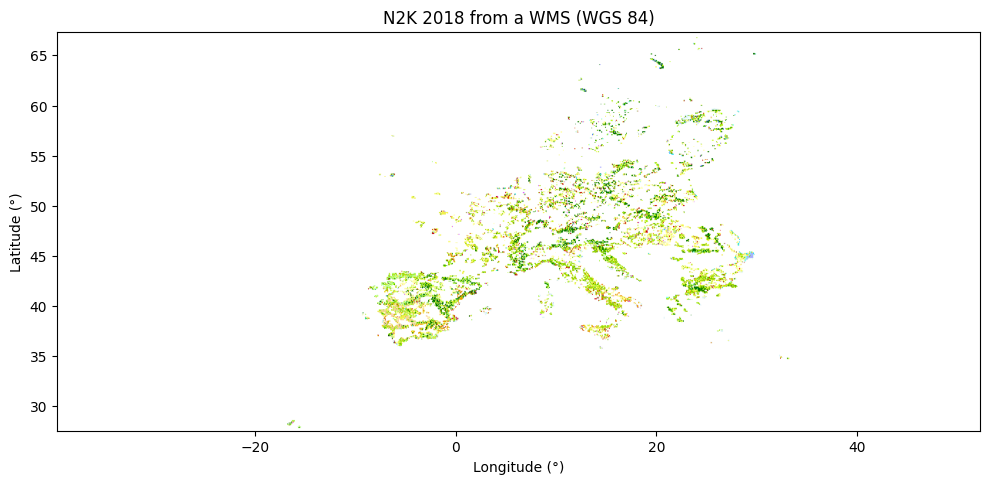

In [47]:
response = wms.getmap(
    layers=[layer_name],
    styles=[""],
    srs="EPSG:4326",
    bbox=bbox,
    size=(1200, 800),
    format="image/png",
    transparent=False,
)
image = plt.imread(BytesIO(response.read()))

# Same bbox as GetMap: x = longitude, y = latitude (degrees)
minx, miny, maxx, maxy = bbox
extent = (minx, maxx, miny, maxy)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image, extent=extent, origin="upper", aspect="equal")
ax.set_title("N2K 2018 from a WMS (WGS 84)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


Focus bbox (EPSG:4326): (-5.5, 40.0, -3.0, 42.5)


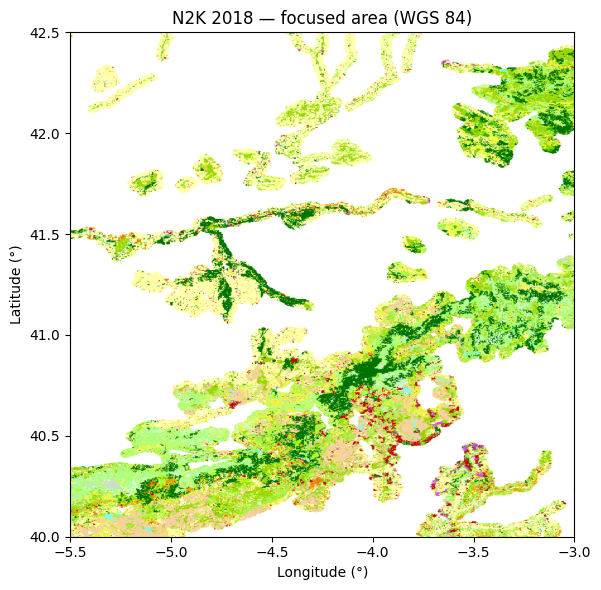

In [48]:
# Focus on a specific area (EPSG:4326: min_lon, min_lat, max_lon, max_lat).
# Values must overlap the layer extent printed above.

area_of_interest = (-5.5, 40.0, -3.0, 42.5)

full_minx, full_miny, full_maxx, full_maxy = bbox
a0, a1, a2, a3 = area_of_interest
focus_minx = max(a0, full_minx)
focus_miny = max(a1, full_miny)
focus_maxx = min(a2, full_maxx)
focus_maxy = min(a3, full_maxy)

focus_bbox = (focus_minx, focus_miny, focus_maxx, focus_maxy)
print("Focus bbox (EPSG:4326):", focus_bbox)

response_focus = wms.getmap(
    layers=[layer_name],
    styles=[""],
    srs="EPSG:4326",
    bbox=focus_bbox,
    size=(1200, 800),
    format="image/png",
    transparent=False,
)
raster_focus = plt.imread(BytesIO(response_focus.read()))

fx0, fy0, fx1, fy1 = focus_bbox
extent_focus = (fx0, fx1, fy0, fy1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(raster_focus, extent=extent_focus, origin="upper", aspect="equal")
ax.set_title("N2K 2018 — focused area (WGS 84)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


## Activity 1. Can you focus on Balearic Islands?

Note: the image is a Numpy variable

In [49]:
type(image)

numpy.ndarray

In [50]:
# As the image is a Numpy variable, you can use the same indexing as a matrix.
# For example, to get the first row, you can do:
image[0, :, :]



array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       ...,
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], shape=(1200, 3), dtype=float32)

In [51]:
# Min/max over the whole array (all rows, columns, and colour channels)
image.min(), image.max()


(np.float32(0.0), np.float32(1.0))

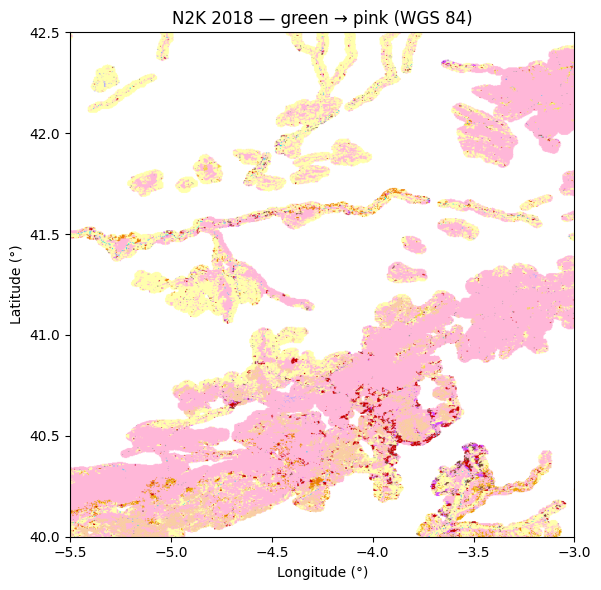

In [52]:
# Map green-dominant pixels to pink (RGB). Uses the focused raster, not the full-extent `image`.
# `plt.imread` usually gives floats in [0, 1] for PNG; thresholds are in that range.

displayed = raster_focus.copy()

r = displayed[..., 0]
g = displayed[..., 1]
b = displayed[..., 2]

# Pixels that look "green" in RGB: G channel is highest and strong enough
green_mask = (g > r) & (g > b) & (g > 0.2)

# Pink target (RGB in [0, 1]): high red and blue, moderate green
displayed[..., 0][green_mask] = 1.0
displayed[..., 1][green_mask] = 0.72
displayed[..., 2][green_mask] = 0.85
# Alpha channel (if present) is left unchanged

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(displayed, extent=extent_focus, origin="upper", aspect="equal")
ax.set_title("N2K 2018 — green → pink (WGS 84)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


## Saving the map

- **Matplotlib** (`plt.imsave`): guarda un array NumPy (por ejemplo `displayed` tras el procesado) como PNG.
- **OWSLib** (`wms.getmap`): el valor devuelto es la respuesta HTTP; usa `.read()` una vez y escribe esos **bytes** en un fichero para guardar exactamente lo que envía el WMS (antes de `imread`).


In [53]:
from pathlib import Path

out_dir = Path("data")

# 1) Matplotlib: guardar la imagen ya procesada (array → PNG)
plt.imsave(out_dir / "n2k_focus_displayed.png", displayed)

# 2) OWSLib: guardar el PNG crudo del WMS (misma petición que la vista enfocada)
_resp = wms.getmap(
    layers=[layer_name],
    styles=[""],
    srs="EPSG:4326",
    bbox=focus_bbox,
    size=(1200, 800),
    format="image/png",
    transparent=False,
)
png_bytes = _resp.read()
(out_dir / "n2k_focus_raw_wms.png").write_bytes(png_bytes)

print("Guardado:", out_dir / "n2k_focus_displayed.png")
print("Guardado:", out_dir / "n2k_focus_raw_wms.png")


Guardado: data/n2k_focus_displayed.png
Guardado: data/n2k_focus_raw_wms.png


## Rasterio: clipping with `mask`



### Simpler option when you only need a **rectangle**


For a **rectangle inset** aligned with the image (same as the `box` above), the WMS image is sampled **uniformly** over `focus_bbox` in EPSG:4326, so you can **crop pixels with NumPy** — no extra library, no `MemoryFile`:

```python
rin = round(h * 0.15)
cin = round(w * 0.15)
crop_simple = raster_focus[rin : h - rin, cin : w - cin, :]
```

Use **Rasterio `mask`** when you need **non-rectangular** geometries, **reprojection**, or **exact** geodetic clipping — not just equal pixel margins.


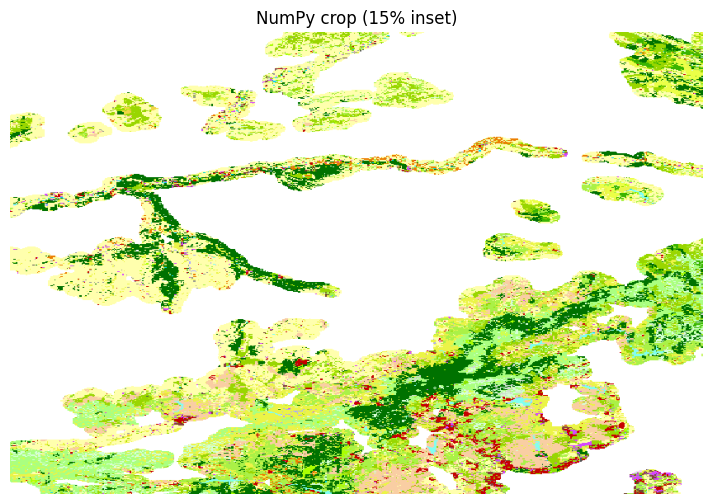

In [54]:
# Same 15% inset as the clip example above, in pixel space (no Rasterio)
h, w = raster_focus.shape[0], raster_focus.shape[1]
rin = round(h * 0.15)
cin = round(w * 0.15)
crop_simple = raster_focus[rin : h - rin, cin : w - cin, :]

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(crop_simple)
ax.set_title("NumPy crop (15% inset)")
ax.axis("off")
plt.show()


## Clasificación simple para extraer características (píxeles)

La imagen WMS es **RGB** (no una sola “banda 1” con valores 0–255 fijos). Para resaltar zonas con **respuesta espectral más verde** (proxy de vegetación en este mapa), usamos el índice **Excess Green**:

`ExG = 2G - R - B` sobre `R,G,B` normalizados a `[0,1]`.

- **Binario:** `np.where(ExG > umbral, 1, 0)`.
- **Varias clases:** umbrales sobre `ExG` (p. ej. 0, 0.06, 0.14) asignando 0…3.

Los umbrales son orientativos; ajústalos al contraste de la imagen.


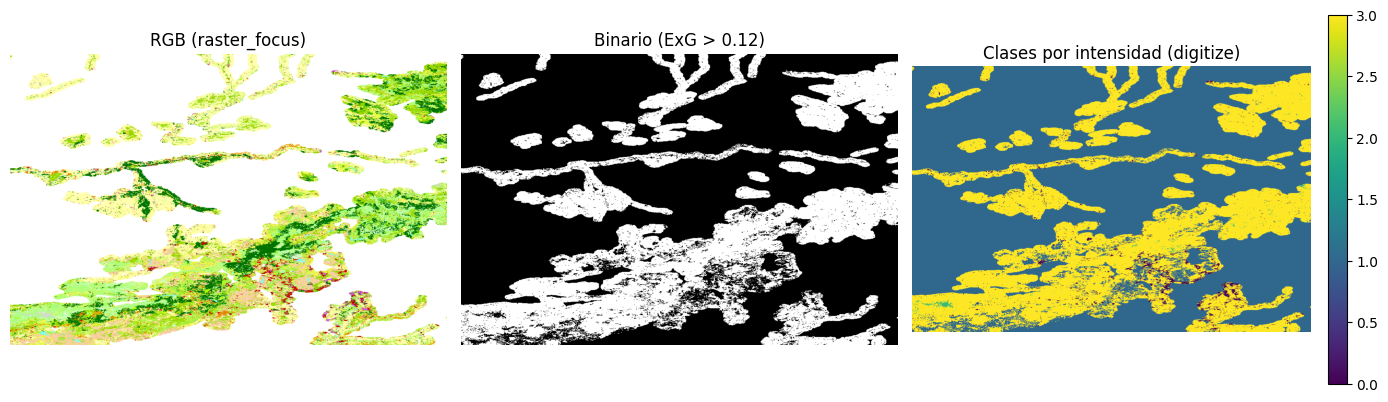

Píxeles clase 1 (binario): 330339 de 960000


In [55]:
import numpy as np

rgb = raster_focus[..., :3].astype(np.float32)
if rgb.max() > 1.0:
    rgb = rgb / 255.0

r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
ex_green = 2 * g - r - b  # característica espectral por píxel (ExG)

# Clasificación binaria: zonas con ExG alto
t_bin = 0.12
classified = np.where(ex_green > t_bin, 1, 0).astype(np.uint8)

# Cuatro niveles de intensidad de ExG (clases 0–3)
classes_k = np.zeros_like(ex_green, dtype=np.uint8)
classes_k[ex_green >= 0.0] = 1
classes_k[ex_green >= 0.06] = 2
classes_k[ex_green >= 0.14] = 3

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(rgb)
axes[0].set_title("RGB (raster_focus)")
axes[0].axis("off")
axes[1].imshow(classified, cmap="Greys_r", vmin=0, vmax=1)
axes[1].set_title(f"Binario (ExG > {t_bin})")
axes[1].axis("off")
im = axes[2].imshow(classes_k, cmap="viridis", vmin=0, vmax=3)
axes[2].set_title("Clases por intensidad (umbrales en ExG)")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("Píxeles clase 1 (binario):", int(classified.sum()), "de", classified.size)


### Guardar la clasificación como GeoTIFF

Mismo **`focus_bbox`** (EPSG:4326) y dimensiones que `raster_focus`, usando `rasterio.transform.from_bounds` como en la sección de recorte.

Se escriben tres GeoTIFF en `data/`: binario, multiclase, y banda flotante `ExG`.


In [56]:
from pathlib import Path

import rasterio
from rasterio.transform import from_bounds

out_dir = Path("data")
out_dir.mkdir(parents=True, exist_ok=True)

height, width = classified.shape
minx, miny, maxx, maxy = focus_bbox
transform = from_bounds(minx, miny, maxx, maxy, width, height)

base_profile = {
    "driver": "GTiff",
    "height": height,
    "width": width,
    "count": 1,
    "crs": "EPSG:4326",
    "transform": transform,
    "compress": "deflate",
}

path_bin = out_dir / "n2k_focus_classified_binary.tif"
path_multi = out_dir / "n2k_focus_classes_multiclass.tif"
path_exg = out_dir / "n2k_focus_ex_green.tif"

with rasterio.open(path_bin, "w", dtype="uint8", **base_profile) as dst:
    dst.write(classified[np.newaxis, ...])

with rasterio.open(path_multi, "w", dtype="uint8", **base_profile) as dst:
    dst.write(classes_k[np.newaxis, ...])

with rasterio.open(path_exg, "w", dtype="float32", **base_profile) as dst:
    dst.write(ex_green.astype(np.float32)[np.newaxis, ...])

print("Escritos:", path_bin)
print("Escritos:", path_multi)
print("Escritos:", path_exg)


Escritos: data/n2k_focus_classified_binary.tif
Escritos: data/n2k_focus_classes_multiclass.tif
Escritos: data/n2k_focus_ex_green.tif


## Activity 2. “El Verdor” (%) sobre un área — p. ej. Islas Baleares

**Objetivo:** estimar qué fracción de la superficie de interés se clasifica como **alta respuesta “verde”** (según el índice ExG y un umbral), respecto al total de la zona analizada.

### Planteamiento sugerido

1. **Delimitar el área de estudio (AOI)**  
   - Sencillo: un rectángulo `area_of_interest` que cubra Baleares (lon/lat en EPSG:4326), como ya haces con el foco.  

2. **Obtener la imagen WMS** para ese `bbox` (misma capa y `srs=EPSG:4326`) y calcular **ExG** y la **máscara binaria** `classified` (misma lógica que en el notebook).

3. **Definir “verdor”** de forma explícita, p. ej. `classified == 1` (ExG > `t_bin`) o clases ≥ 2 en `classes_k` si quieres “verdor medio-alto”.

4. **Calcular el porcentaje**  
   - *Sobre el rectángulo de la petición (rápido):*  
     `100 * classified.sum() / classified.size`  
     (asume que todos los píxeles del raster cuentan igual; válido para comparar umbrales entre ejecuciones).
   - *Sobre el polígono de islas (mejor):* enmascarar con el polígono y usar solo píxeles dentro del AOI:  
     `100 * verdes_en_aoi / píxeles_en_aoi`.

   - **(NOTA, no es superficie real)**  en EPSG:4326 el tamaño de píxel en metros varía con la latitud.Habría que reproyectar a un CRS **métrico** y ponderar por **área de celda** en m²
   

